In [8]:
pip install scipy arviz

Note: you may need to restart the kernel to use updated packages.


In [9]:
import numpy as np
import pandas as pd
import scipy as sp
import arviz as az

## Análisis exploratorio  de operaciones T0 y T1.

Cambios en las disteribuciones por variable con y sin fraude.


In [10]:
##pip install --upgrade --force-reinstall pyarrow pandas

In [11]:
operaciones_T0 = pd.read_parquet("/Users/Usuario/Downloads/banco-anfora-bayes-fraud/data/raw/operaciones_T0_train.parquet")

In [108]:
operaciones_T1_etiquetadas = pd.read_parquet("/Users/Usuario/Downloads/operaciones_T1_etiquetadas.parquet")

In [102]:
operaciones_T1_etiquetadas.groupby(['es_fraude', 'dispositivo']).size()

es_fraude  dispositivo        
False      conocido               138917
           desconocido             12443
           registrado_reciente     26753
True       conocido                  443
           desconocido              1352
           registrado_reciente       457
dtype: int64

In [35]:
percent_t0 = operaciones_T0.groupby('es_fraude').size() / len(operaciones_T0)
percent_t1 = operaciones_T1_etiquetadas.groupby('es_fraude').size() / len(operaciones_T1_etiquetadas)
print('T0:', percent_t0)
print('T1:', percent_t1)



T0: es_fraude
False    0.992021
True     0.007979
dtype: float64
T1: es_fraude
False    0.987514
True     0.012486
dtype: float64


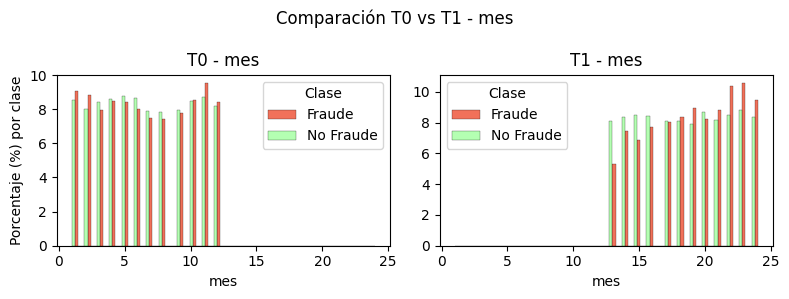

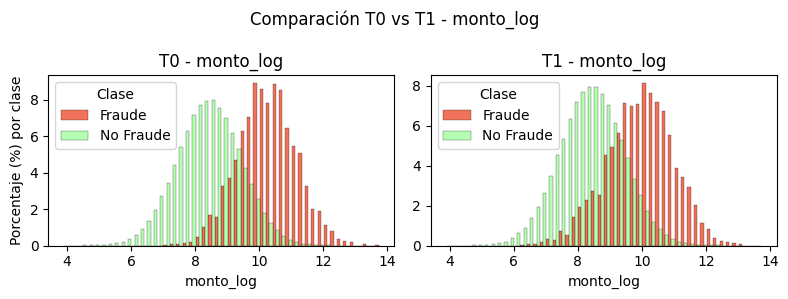

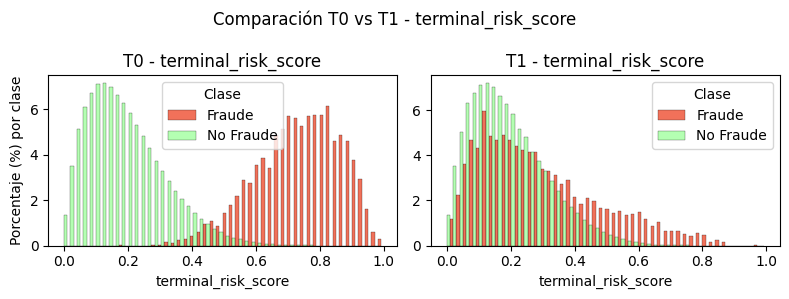

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

excluir = ['op_id', 'secuencia_24h']

# Variables numéricas comunes entre T0 y T1
numericas_T0 = operaciones_T0.select_dtypes(include=['number']).drop(columns=excluir, errors='ignore')
numericas_T1 = operaciones_T1_etiquetadas.select_dtypes(include=['number']).drop(columns=excluir, errors='ignore')

cols_comunes = numericas_T0.columns.intersection(numericas_T1.columns)

# Ajustar según cómo esté codificada es_fraude
palette_fraude = {
    True: "#ED4123",    # Fraude
    False: "#9BFF99"    # No Fraude
}

for col in cols_comunes:

    fig, axes = plt.subplots(1, 2, figsize=(8, 3))

    # Para que ambos gráficos usen los mismos bins
    min_val = min(operaciones_T0[col].min(), operaciones_T1_etiquetadas[col].min())
    max_val = max(operaciones_T0[col].max(), operaciones_T1_etiquetadas[col].max())
    bins = np.linspace(min_val, max_val)  # Ajusta el número de bins según convenga

    sns.histplot(
        data=operaciones_T0,
        x=col,
        hue='es_fraude',
        stat='percent',
        common_norm=False,
        multiple='dodge',
        palette=palette_fraude,
        binrange=(min_val, max_val),
        bins=bins,
        ax=axes[0]
    )

    axes[0].set_title(f'T0 - {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Porcentaje (%) por clase')

    sns.histplot(
        data=operaciones_T1_etiquetadas,
        x=col,
        hue='es_fraude',
        stat='percent',
        common_norm=False,
        multiple='dodge',
        palette=palette_fraude,
        binrange=(min_val, max_val),
        bins=bins,
        ax=axes[1],

    )

    axes[1].set_title(f'T1 - {col}')
    axes[1].set_xlabel(col)
    axes[1].set_ylabel('')


    # Mejorar leyendas
    for ax in axes:
        handles, labels = ax.get_legend_handles_labels()
        if ax.get_legend() is not None:
            ax.legend(title='Clase', labels=['Fraude', 'No Fraude'])

    fig.suptitle(f'Comparación T0 vs T1 - {col}', fontsize=12)
    plt.tight_layout()
    plt.show()


###  Análisis T0 vs T1:

Aumento del 0,46 puntos porcentuales en la proporción de operaciones con fraude entre el 2024 y el 2025: Es decir, en el 2024, Las operaciones con fraude son el 0,79% del total de operaciones, mientras que en T1 pasan a ser el 1,25% de las opraciones. 


#### Comparación de las distribuciones de los porcentajes de las operaciones a lo largo de los meses, normalizadas por clase: 

Mientras que en el 2024 (T0) no se ven diferencias notables entre las distribuciones de ambas clases, en el 2025 (T1) se ve una notable diferencia entre ambas distribuciones. Mientras que las proporción de operaciones sin fraude en 2025, fluctua de forma leve a lo largo de los meses, las operaciones con fraude, tiene una pendiente creciente y relativamente contante a lo largo del periodo.



#### Montos_ Log: 

La distribución de los montos cohincide más entre las operaciones con fraude y sin fraude. 


#### terminal_risk_score:

Cambio rotundo.






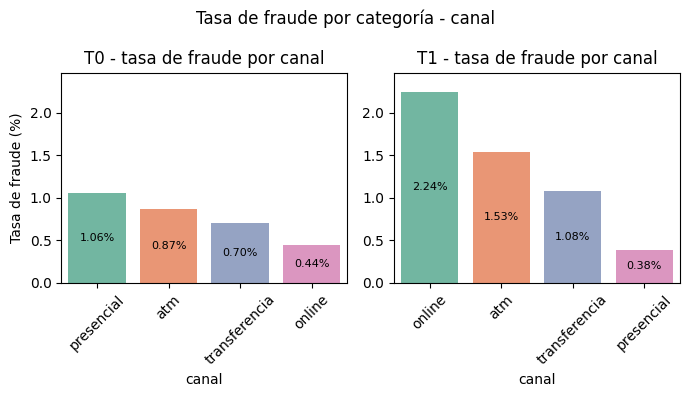

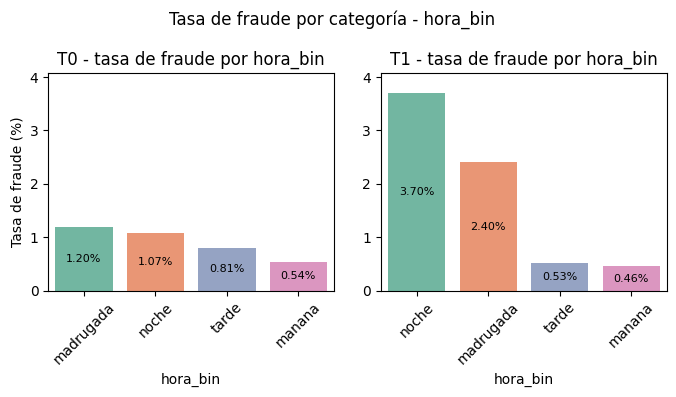

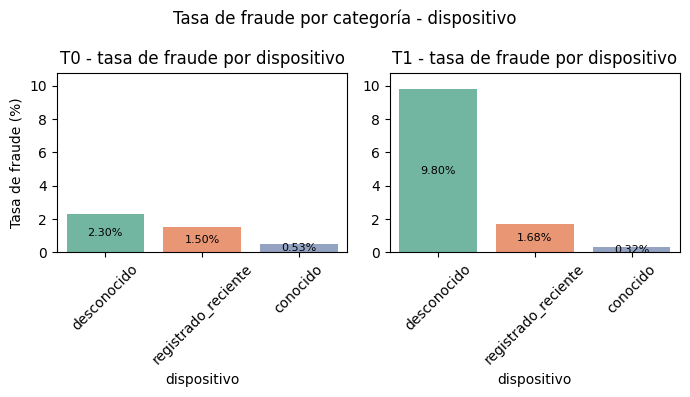

In [67]:


# Variables categoricas comunes entre T0 y T1
categoricas_T0 = operaciones_T0.select_dtypes(include=['object', 'string', 'category'])
categoricas_T1 = operaciones_T1_etiquetadas.select_dtypes(include=['object', 'string', 'category'])

cols_comunes_cat = categoricas_T0.columns.intersection(categoricas_T1.columns)


tablas_T0 = []
tablas_T1 = []

for col in cols_comunes_cat:

    tabla_T0 = (
        operaciones_T0
        .groupby(col)
        .agg(
            total=('es_fraude', 'size'),
            fraudes=('es_fraude', 'sum'),
            tasa_fraude=('es_fraude', 'mean')
        )
        .reset_index()
    )

    tabla_T0['tasa_fraude_pct'] = tabla_T0['tasa_fraude'] * 100
    tablas_T0.append(tabla_T0)

    tabla_T1 = (
        operaciones_T1_etiquetadas
        .groupby(col)
        .agg(
            total=('es_fraude', 'size'),
            fraudes=('es_fraude', 'sum'),
            tasa_fraude=('es_fraude', 'mean')
        )
        .reset_index()
    )

    tabla_T1['tasa_fraude_pct'] = tabla_T1['tasa_fraude'] * 100
    tablas_T1.append(tabla_T1)
    # Mismo rango de eje Y para T0 y T1
    ymax = max(
        tabla_T0['tasa_fraude_pct'].max(),
        tabla_T1['tasa_fraude_pct'].max()
    )

    fig, axes = plt.subplots(1, 2, figsize=(7, 4))

    sns.barplot(
        data=tabla_T0.sort_values('tasa_fraude_pct', ascending=False),
        x=col,
        y='tasa_fraude_pct',
        ax=axes[0],
        palette='Set2',
        hue = col,
        legend=False
    )

    axes[0].set_title(f'T0 - tasa de fraude por {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Tasa de fraude (%)')

    sns.barplot(
        data=tabla_T1.sort_values('tasa_fraude_pct', ascending=False),
        x=col,
        y='tasa_fraude_pct',
        ax=axes[1],
        palette='Set2',
        hue = col,
        legend=False
    )

    axes[1].set_title(f'T1 - tasa de fraude por {col}')
    axes[1].set_xlabel(col)
    axes[1].set_ylabel('')

    # Aplicar mismo límite del eje Y
    axes[0].set_ylim(0, ymax * 1.10)
    axes[1].set_ylim(0, ymax * 1.10)

    for ax in axes:
        ax.tick_params(axis='x', rotation=45)
    for container in axes[0].containers:
        axes[0].bar_label(
            container,
            fmt='%.2f%%',
            label_type='center',
            fontsize=8
        )
    for container in axes[1].containers:
        axes[1].bar_label(
            container,
            fmt='%.2f%%',
            label_type='center',
            fontsize=8
        )

    fig.suptitle(f'Tasa de fraude por categoría - {col}', fontsize=12)
    plt.tight_layout()
    plt.show()

In [104]:
## Chequeo de gráficos anteriores: 

categoricas = operaciones_T0.select_dtypes(
    include=['object', 'string', 'category']
)

for col in categoricas.columns:
    
    tabla = (
        operaciones_T0
        .groupby(col)
        .agg(
            total=('es_fraude', 'size'),
            fraudes=('es_fraude', 'sum'),
            tasa_fraude=('es_fraude', 'mean')
        )
        .reset_index()
    )

    tabla['tasa_fraude_pct'] = tabla['tasa_fraude'] * 100
    tabla = tabla.sort_values('tasa_fraude_pct', ascending=False)


tablas_T1[2].sort_values('tasa_fraude_pct', ascending=False)

,dispositivo,total,fraudes,tasa_fraude,tasa_fraude_pct
1,desconocido,13795,1352,0.098007,9.800652
2,registrado_reciente,27210,457,0.016795,1.679530
0,conocido,139360,443,0.003179,0.317882


In [19]:
## Cambio totalmente el comportamiento:

## Describir los cambios

In [110]:
import pandas as pd

metricas_T0_validacion = pd.read_json("/Users/Usuario/Downloads/banco-anfora-bayes-fraud/data/raw/metricas_T0_validacion.json", orient="index")


metricas_T0_validacion

,descripcion,features,threshold,T0_train,T0_validacion
M1_logistica,Regresión logística lineal con 3 features (mon...,"[monto_log, canal, dispositivo]",0.14,"{'n': 420460, 'n_fraude': 3355, 'threshold': 0...","{'n': 180832, 'n_fraude': 1448, 'threshold': 0..."
M2_random_forest,Random Forest con 5 features (incluye hora_bin...,"[monto_log, secuencia_24h, canal, dispositivo,...",0.11,"{'n': 420460, 'n_fraude': 3355, 'threshold': 0...","{'n': 180832, 'n_fraude': 1448, 'threshold': 0..."
M3_gbm_completo,Gradient Boosting completo con 6 features incl...,"[monto_log, secuencia_24h, terminal_risk_score...",0.46,"{'n': 420460, 'n_fraude': 3355, 'threshold': 0...","{'n': 180832, 'n_fraude': 1448, 'threshold': 0..."
M4_gbm_moderado,Gradient Boosting moderado con 5 features (sin...,"[monto_log, secuencia_24h, canal, dispositivo,...",0.11,"{'n': 420460, 'n_fraude': 3355, 'threshold': 0...","{'n': 180832, 'n_fraude': 1448, 'threshold': 0..."
M5_naive_bayes,Naive Bayes Gaussiano con solo 2 features estr...,"[monto_log, secuencia_24h]",0.11,"{'n': 420460, 'n_fraude': 3355, 'threshold': 0...","{'n': 180832, 'n_fraude': 1448, 'threshold': 0..."


In [111]:
# Convertir una columna con un diccionario a columnas separadas: 

Metricas_T0_Val = metricas_T0_validacion['T0_validacion'].apply(pd.Series)

In [140]:
Metricas_T0_Val

,n,n_fraude,threshold,TP,FP,FN,TN,precision,recall,f1,accuracy,auc_roc,auc_pr,f1_score_recalculada
M1_logistica,180832.0,1448.0,0.14,347.0,1065.0,1101.0,178319.0,0.245751,0.239641,0.242657,0.988022,0.912089,0.171716,0.242657
M2_random_forest,180832.0,1448.0,0.11,377.0,1272.0,1071.0,178112.0,0.228623,0.260359,0.243461,0.987043,0.895831,0.161155,0.243461
M3_gbm_completo,180832.0,1448.0,0.46,1176.0,170.0,272.0,179214.0,0.873700,0.812155,0.841804,0.997556,0.996436,0.854691,0.841804
M4_gbm_moderado,180832.0,1448.0,0.11,395.0,1507.0,1053.0,177877.0,0.207676,0.272790,0.235821,0.985843,0.911858,0.148068,0.235821
M5_naive_bayes,180832.0,1448.0,0.11,330.0,1312.0,1118.0,178072.0,0.200974,0.227901,0.213592,0.986562,0.896472,0.137176,0.213592


In [113]:
# sanity check: verificar que las métricas se correspondan con las del modelo M1:

def f1_score(precision, recall):
    if precision + recall == 0:
        return 0.0
    return 2 * (precision * recall) / (precision + recall)


In [114]:
# Quiero agregar una coluna con el f1_score recalculado a partir de precision y recall para cada fila

Metricas_T0_Val['f1_score_recalculada'] = Metricas_T0_Val.apply(lambda row: f1_score(row['precision'], row['recall']), axis=1)

In [115]:
Metricas_T0_Val

,n,n_fraude,threshold,TP,FP,FN,TN,precision,recall,f1,accuracy,auc_roc,auc_pr,f1_score_recalculada
M1_logistica,180832.0,1448.0,0.14,347.0,1065.0,1101.0,178319.0,0.245751,0.239641,0.242657,0.988022,0.912089,0.171716,0.242657
M2_random_forest,180832.0,1448.0,0.11,377.0,1272.0,1071.0,178112.0,0.228623,0.260359,0.243461,0.987043,0.895831,0.161155,0.243461
M3_gbm_completo,180832.0,1448.0,0.46,1176.0,170.0,272.0,179214.0,0.873700,0.812155,0.841804,0.997556,0.996436,0.854691,0.841804
M4_gbm_moderado,180832.0,1448.0,0.11,395.0,1507.0,1053.0,177877.0,0.207676,0.272790,0.235821,0.985843,0.911858,0.148068,0.235821
M5_naive_bayes,180832.0,1448.0,0.11,330.0,1312.0,1118.0,178072.0,0.200974,0.227901,0.213592,0.986562,0.896472,0.137176,0.213592


## Paso 2. Primer posterior Beta-Binomial sobre un solo modelo
Tomar M3 y la validación T0 entera. 

#### Construir dos posteriores Beta-Binomial conjugadas: 
    una sobre la precisión, p | datos ∼ Beta(1 + TP, 1 + FP), 
    y otra sobre la sensibilidad, r | datos ∼ Beta(1 + TP, 1 + FN). 
    
    Con prior uniforme Beta(1, 1), esa es la actualización conjugada estándar.

Reportar mediana y HPDI 95 % de cada una.

Lo importante de este paso no es el número en sí sino tener dos cosas claras: 
(i) por qué la elección Beta-Binomial es natural — el dato es una secuencia de éxitos y fracasos, y la
posterior conjugada es Beta; 

(ii) qué supone la posterior — que precisión y sensibilidad son?

In [116]:
#### Construir dos posteriores Beta-Binomial conjugadas: 
# una sobre la precisión, p | datos ∼ Beta(1 + TP, 1 + FP), 
# y otra sobre la sensibilidad, r | datos ∼ Beta(1 + TP, 1 + FN). 
# Con prior uniforme Beta(1, 1), esa es la actualización conjugada estándar.

Metricas_T0_Val

,n,n_fraude,threshold,TP,FP,FN,TN,precision,recall,f1,accuracy,auc_roc,auc_pr,f1_score_recalculada
M1_logistica,180832.0,1448.0,0.14,347.0,1065.0,1101.0,178319.0,0.245751,0.239641,0.242657,0.988022,0.912089,0.171716,0.242657
M2_random_forest,180832.0,1448.0,0.11,377.0,1272.0,1071.0,178112.0,0.228623,0.260359,0.243461,0.987043,0.895831,0.161155,0.243461
M3_gbm_completo,180832.0,1448.0,0.46,1176.0,170.0,272.0,179214.0,0.873700,0.812155,0.841804,0.997556,0.996436,0.854691,0.841804
M4_gbm_moderado,180832.0,1448.0,0.11,395.0,1507.0,1053.0,177877.0,0.207676,0.272790,0.235821,0.985843,0.911858,0.148068,0.235821
M5_naive_bayes,180832.0,1448.0,0.11,330.0,1312.0,1118.0,178072.0,0.200974,0.227901,0.213592,0.986562,0.896472,0.137176,0.213592


In [117]:
from scipy.stats import beta
import numpy as np
import matplotlib.pyplot as plt


# Prior
a_prior = 1
b_prior = 1

results = {}

for idx in range(len(Metricas_T0_Val)):
    model = Metricas_T0_Val.index[idx]

    # Datos
    TP = Metricas_T0_Val['TP'].iloc[idx]
    FP = Metricas_T0_Val['FP'].iloc[idx]
    FN = Metricas_T0_Val['FN'].iloc[idx]

    # Posterior
    a_post_P_i = a_prior + TP
    b_post_P_i = b_prior + FP

    a_post_R_i = a_prior + TP
    b_post_R_i = b_prior + FN

    x = np.linspace(0, 1, 100)

    prior_P = beta.pdf(x, a_prior, b_prior)
    posterior_P = beta.pdf(x, a_post_P_i, b_post_P_i)

    prior_R = beta.pdf(x, a_prior, b_prior)
    posterior_R = beta.pdf(x, a_post_R_i, b_post_R_i)

    results[model] = {
        "TP": TP, "FP": FP, "FN": FN,
        "a_post_P": a_post_P_i, "b_post_P": b_post_P_i,
        "a_post_R": a_post_R_i, "b_post_R": b_post_R_i,
        "x": x, "prior_P": prior_P, "posterior_P": posterior_P,
        "prior_R": prior_R, "posterior_R": posterior_R
    }






In [ ]:
results['M3_gbm_completo']['a_post_P']

(np.float64(1177.0), np.float64(171.0), np.float64(1177.0), np.float64(273.0))

In [ ]:
# Media y varianza posterior precisión

for model, res in results.items():
    a_post_P = res["a_post_P"]
    b_post_P = res["b_post_P"]
    a_post_R = res["a_post_R"]
    b_post_R = res["b_post_R"]

    mean_P = a_post_P / (a_post_P + b_post_P)
    var_P = (a_post_P * b_post_P) / ((a_post_P + b_post_P)**2 * (a_post_P + b_post_P + 1))

    # Media y varianza posterior recall
    mean_R = a_post_R / (a_post_R + b_post_R)
    var_R = (a_post_R * b_post_R) / ((a_post_R + b_post_R)**2 * (a_post_R + b_post_R + 1))

    print(f"{model} - Precisión: Media={mean_P:.4f}, Varianza={var_P:.8f}")
    print(f"{model} - Recall: Media={mean_R:.4f}, Varianza={var_R:.8f}")
    print()



M1_logistica - Precisión: Media=0.2461, Varianza=0.00013112
M1_logistica - Recall: Media=0.2400, Varianza=0.00012571

M2_random_forest - Precisión: Media=0.2290, Varianza=0.00010686
M2_random_forest - Recall: Media=0.2607, Varianza=0.00013283

M3_gbm_completo - Precisión: Media=0.8731, Varianza=0.00008211
M3_gbm_completo - Recall: Media=0.8117, Varianza=0.00010533

M4_gbm_moderado - Precisión: Media=0.2080, Varianza=0.00008647
M4_gbm_moderado - Recall: Media=0.2731, Varianza=0.00013681

M5_naive_bayes - Precisión: Media=0.2013, Varianza=0.00009775
M5_naive_bayes - Recall: Media=0.2283, Varianza=0.00012141



In [118]:

# --------------------------
# Función para calcular HPDI
# --------------------------
def hpdi(samples, prob=0.95):
    samples = np.sort(samples)
    n = len(samples)
    interval_idx_inc = int(np.floor(prob * n))
    
    interval_width = samples[interval_idx_inc:] - samples[:n - interval_idx_inc]
    min_idx = np.argmin(interval_width)
    
    hdi_min = samples[min_idx]
    hdi_max = samples[min_idx + interval_idx_inc]
    
    return hdi_min, hdi_max

In [119]:
# Cantidad de simulaciones
S = 100_000

for model, res in results.items():
    a_post_P = res["a_post_P"]
    b_post_P = res["b_post_P"]
    a_post_R = res["a_post_R"]
    b_post_R = res["b_post_R"]

    # -----------------------------
    # Precisión
    # -----------------------------
    mean_P = a_post_P / (a_post_P + b_post_P)
    var_P = (a_post_P * b_post_P) / (
        (a_post_P + b_post_P)**2 * (a_post_P + b_post_P + 1)
    )

    samples_P = beta.rvs(
        a_post_P,
        b_post_P,
        size=S,
        random_state=42
    )

    median_P = np.median(samples_P)
    hpdi_P = hpdi(samples_P, prob=0.95)

    # -----------------------------
    # Recall / Sensibilidad
    # -----------------------------
    mean_R = a_post_R / (a_post_R + b_post_R)
    var_R = (a_post_R * b_post_R) / (
        (a_post_R + b_post_R)**2 * (a_post_R + b_post_R + 1)
    )

    samples_R = beta.rvs(
        a_post_R,
        b_post_R,
        size=S,
        random_state=123
    )

    median_R = np.median(samples_R)
    hpdi_R = hpdi(samples_R, prob=0.95)

    # -----------------------------
    # Guardar resultados en el diccionario
    # -----------------------------
    results[model]["mean_P"] = mean_P
    results[model]["var_P"] = var_P
    results[model]["median_P"] = median_P
    results[model]["hpdi_P"] = hpdi_P

    results[model]["mean_R"] = mean_R
    results[model]["var_R"] = var_R
    results[model]["median_R"] = median_R
    results[model]["hpdi_R"] = hpdi_R

    # -----------------------------
    # Print
    # -----------------------------
    print(f"Modelo: {model}")

    print("Precisión")
    print(f"Media:    {mean_P:.4f}")
    print(f"Varianza: {var_P:.8f}")
    print(f"Mediana:  {median_P:.4f}")
    print(f"HPDI 95%: [{hpdi_P[0]:.4f}, {hpdi_P[1]:.4f}]")

    print("\nRecall / Sensibilidad")
    print(f"Media:    {mean_R:.4f}")
    print(f"Varianza: {var_R:.8f}")
    print(f"Mediana:  {median_R:.4f}")
    print(f"HPDI 95%: [{hpdi_R[0]:.4f}, {hpdi_R[1]:.4f}]")

    print("-" * 50)

Modelo: M1_logistica
Precisión
Media:    0.2461
Varianza: 0.00013112
Mediana:  0.2460
HPDI 95%: [0.2240, 0.2689]

Recall / Sensibilidad
Media:    0.2400
Varianza: 0.00012571
Mediana:  0.2398
HPDI 95%: [0.2180, 0.2618]
--------------------------------------------------
Modelo: M2_random_forest
Precisión
Media:    0.2290
Varianza: 0.00010686
Mediana:  0.2289
HPDI 95%: [0.2084, 0.2490]

Recall / Sensibilidad
Media:    0.2607
Varianza: 0.00013283
Mediana:  0.2606
HPDI 95%: [0.2387, 0.2837]
--------------------------------------------------
Modelo: M3_gbm_completo
Precisión
Media:    0.8731
Varianza: 0.00008211
Mediana:  0.8733
HPDI 95%: [0.8553, 0.8909]

Recall / Sensibilidad
Media:    0.8117
Varianza: 0.00010533
Mediana:  0.8118
HPDI 95%: [0.7915, 0.8315]
--------------------------------------------------
Modelo: M4_gbm_moderado
Precisión
Media:    0.2080
Varianza: 0.00008647
Mediana:  0.2079
HPDI 95%: [0.1893, 0.2258]

Recall / Sensibilidad
Media:    0.2731
Varianza: 0.00013681
Mediana: 

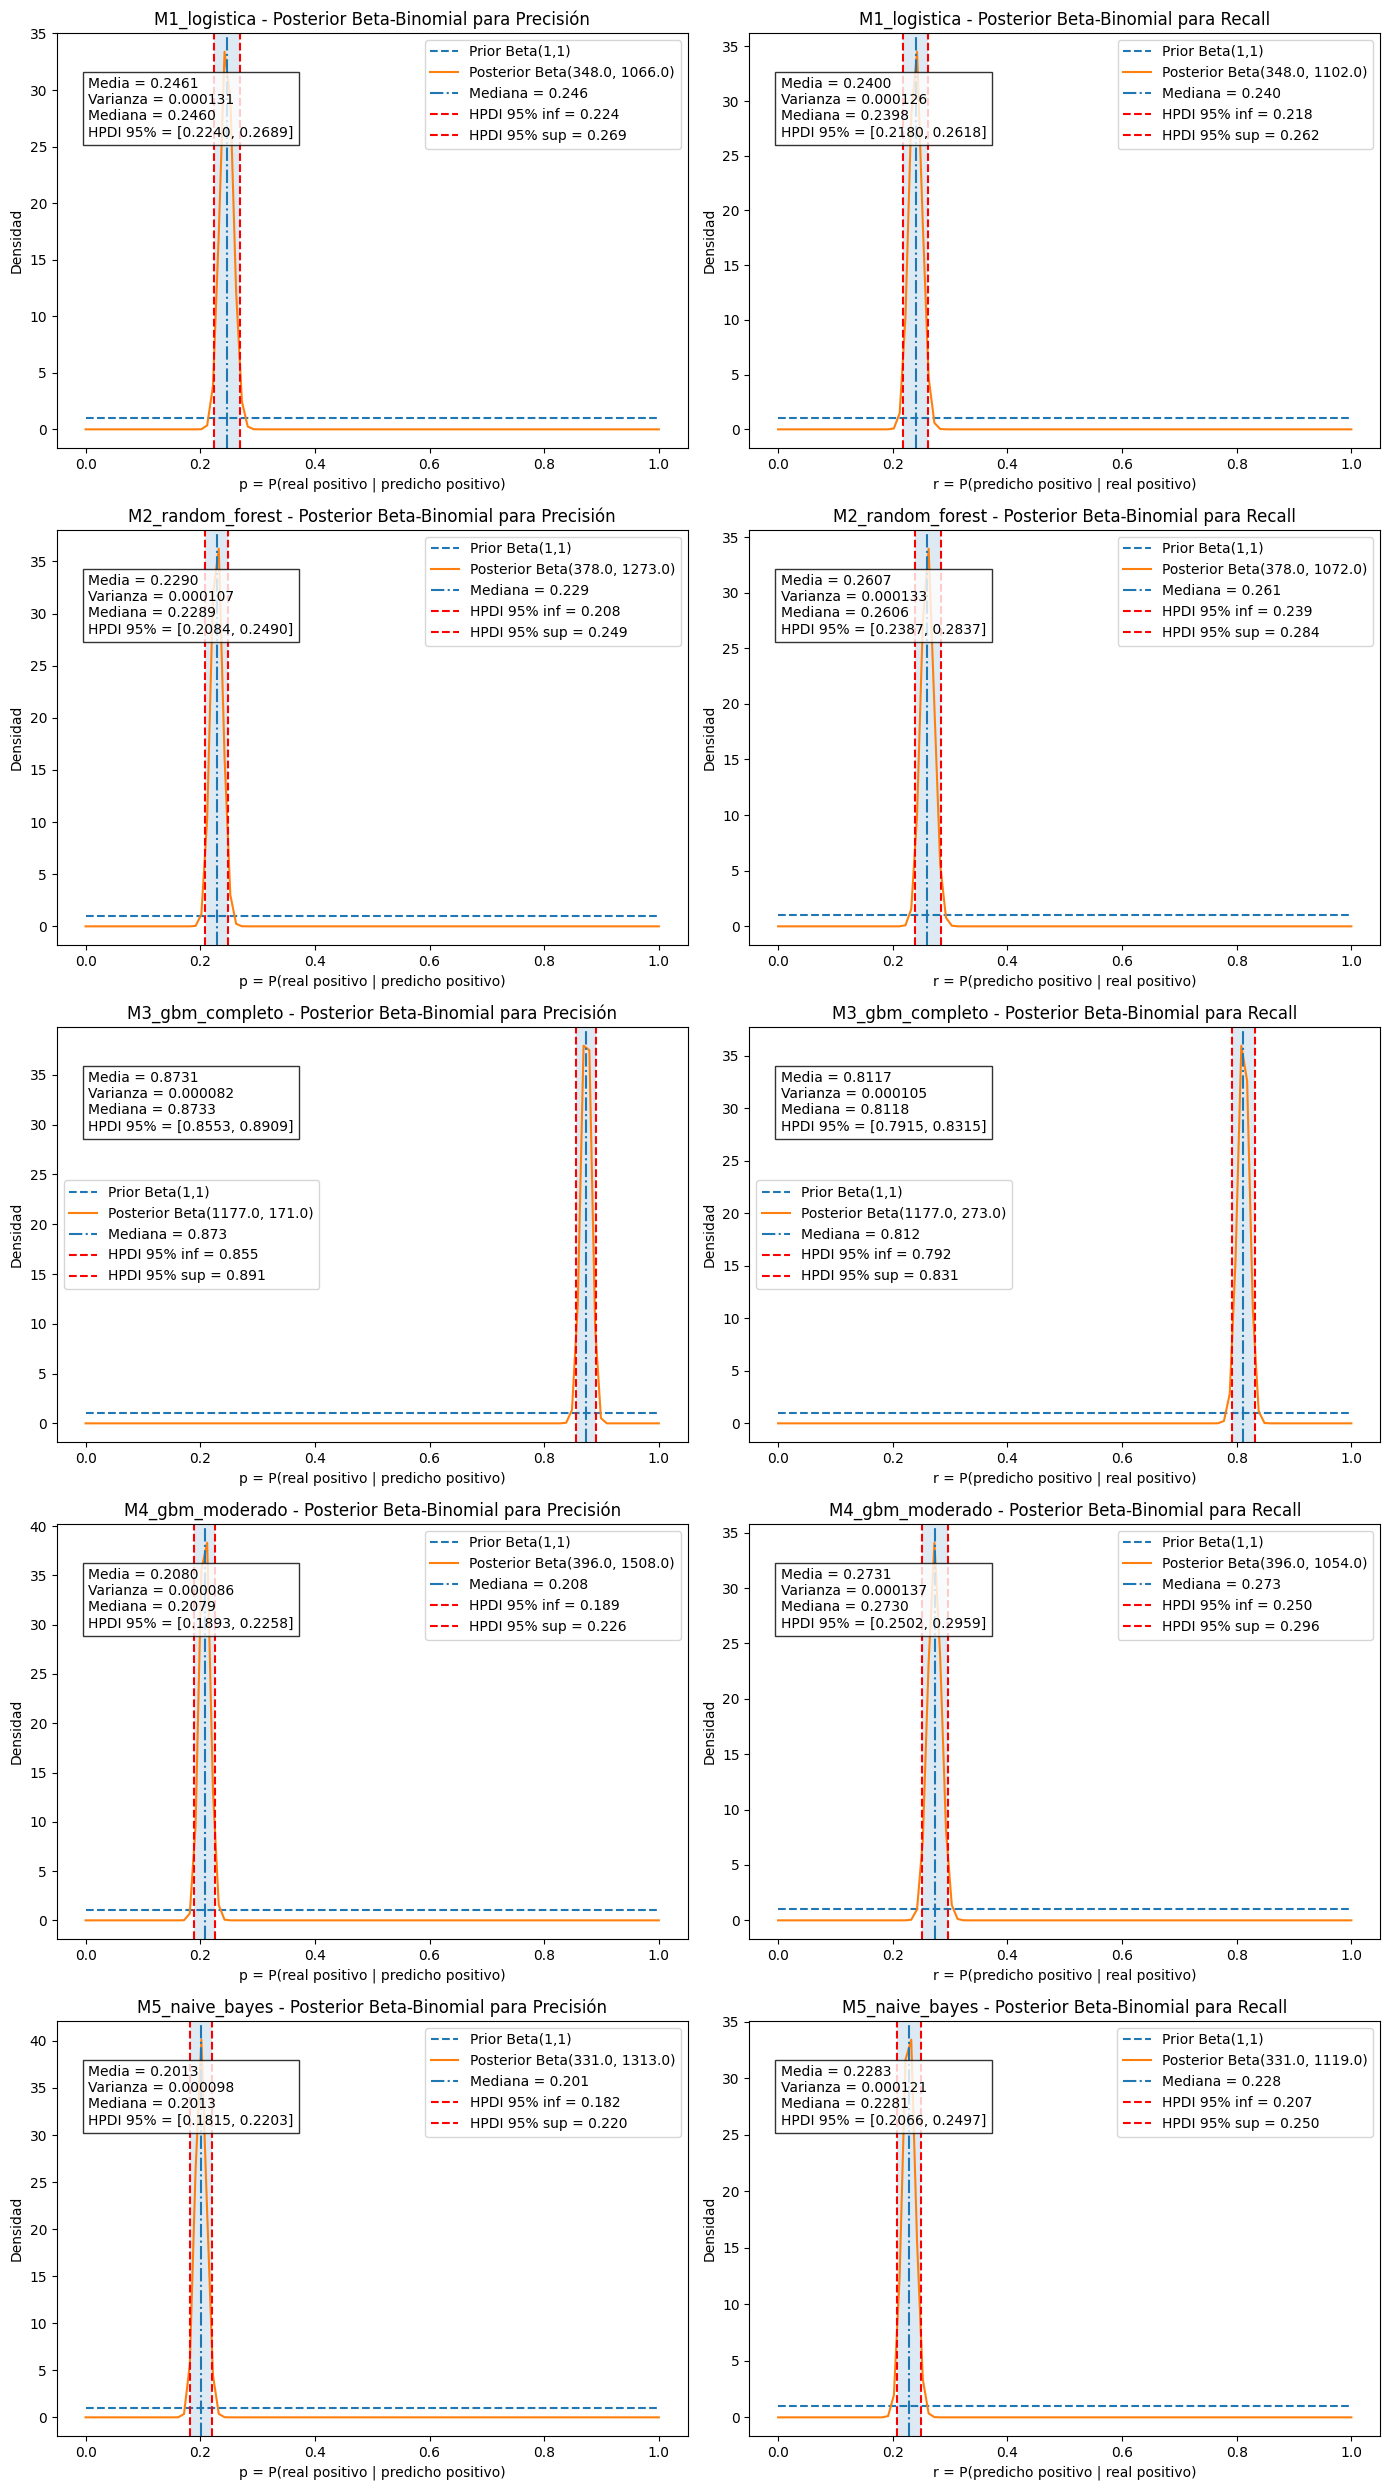

In [120]:
import numpy as np
import matplotlib.pyplot as plt

n_models = len(results)

# Crear figura: una fila por modelo, 2 columnas (Precisión y Recall)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 5 * n_models))

# Si hay un solo modelo, axes viene como vector de longitud 2.
# Lo convertimos a forma (1, 2) para iterar igual que siempre.
if n_models == 1:
    axes = np.array([axes])

for i, (model, res) in enumerate(results.items()):
    
    # Recuperar valores guardados
    x = res["x"]
    
    prior_P = res["prior_P"]
    posterior_P = res["posterior_P"]
    a_post_P = res["a_post_P"]
    b_post_P = res["b_post_P"]
    mean_P = res["mean_P"]
    var_P = res["var_P"]
    median_P = res["median_P"]
    hpdi_P = res["hpdi_P"]

    prior_R = res["prior_R"]
    posterior_R = res["posterior_R"]
    a_post_R = res["a_post_R"]
    b_post_R = res["b_post_R"]
    mean_R = res["mean_R"]
    var_R = res["var_R"]
    median_R = res["median_R"]
    hpdi_R = res["hpdi_R"]

    # ==========================
    # Columna 1: Precisión
    # ==========================
    ax = axes[i, 0]

    ax.plot(x, prior_P, label="Prior Beta(1,1)", linestyle="--")
    ax.plot(x, posterior_P, label=f"Posterior Beta({a_post_P}, {b_post_P})")

    # Mediana y HPDI
    ax.axvline(median_P, linestyle="-.", label=f"Mediana = {median_P:.3f}")
    ax.axvline(hpdi_P[0], linestyle="--", color="red", label=f"HPDI 95% inf = {hpdi_P[0]:.3f}")
    ax.axvline(hpdi_P[1], linestyle="--", color="red", label=f"HPDI 95% sup = {hpdi_P[1]:.3f}")

    # Opcional: sombrear el HPDI
    ax.axvspan(hpdi_P[0], hpdi_P[1], alpha=0.15)

    # Texto dentro del gráfico
    ax.text(
        0.05, 0.75,
        f"Media = {mean_P:.4f}\n"
        f"Varianza = {var_P:.6f}\n"
        f"Mediana = {median_P:.4f}\n"
        f"HPDI 95% = [{hpdi_P[0]:.4f}, {hpdi_P[1]:.4f}]",
        transform=ax.transAxes,
        bbox=dict(facecolor="white", alpha=0.8)
    )

    ax.set_title(f"{model} - Posterior Beta-Binomial para Precisión")
    ax.set_xlabel("p = P(real positivo | predicho positivo)")
    ax.set_ylabel("Densidad")
    ax.legend()

    # ==========================
    # Columna 2: Recall
    # ==========================
    ax = axes[i, 1]

    ax.plot(x, prior_R, label="Prior Beta(1,1)", linestyle="--")
    ax.plot(x, posterior_R, label=f"Posterior Beta({a_post_R}, {b_post_R})")

    # Mediana y HPDI
    ax.axvline(median_R, linestyle="-.", label=f"Mediana = {median_R:.3f}")
    ax.axvline(hpdi_R[0], linestyle="--", color="red", label=f"HPDI 95% inf = {hpdi_R[0]:.3f}")
    ax.axvline(hpdi_R[1], linestyle="--", color="red", label=f"HPDI 95% sup = {hpdi_R[1]:.3f}")

    # Opcional: sombrear el HPDI
    ax.axvspan(hpdi_R[0], hpdi_R[1], alpha=0.15)

    # Texto dentro del gráfico
    ax.text(
        0.05, 0.75,
        f"Media = {mean_R:.4f}\n"
        f"Varianza = {var_R:.6f}\n"
        f"Mediana = {median_R:.4f}\n"
        f"HPDI 95% = [{hpdi_R[0]:.4f}, {hpdi_R[1]:.4f}]",
        transform=ax.transAxes,
        bbox=dict(facecolor="white", alpha=0.8)
    )

    ax.set_title(f"{model} - Posterior Beta-Binomial para Recall")
    ax.set_xlabel("r = P(predicho positivo | real positivo)")
    ax.set_ylabel("Densidad")
    ax.legend()

plt.tight_layout()
plt.show()

### Paso 3.  Propagación Monte Carlo a F1. F1 no tiene posterior conjugado en forma cerrada porque combina precisión y sensibilidad. 

Se obtiene por simulación: muestrear S ≥ 5 000 valores conjuntos (p (s) , r(s) ), calcular F (s) 1 = 2p (s) r (s)/(p (s) +r (s) ) para cada s, y reportar mediana y HPDI 95 % del vector resultante. Verificar que el HPDI cubra el F1 puntual ≈ 0,842 del paso 1; si no lo cubre, hay un error de cómputo.

In [121]:
import numpy as np
from scipy.stats import beta

# Cantidad de simulaciones
S = 100_000

# Semilla reproducible
rng = np.random.default_rng(42)

for model, res in results.items():

    # Parámetros posteriores de precisión
    a_post_P = res["a_post_P"]
    b_post_P = res["b_post_P"]

    # Parámetros posteriores de recall
    a_post_R = res["a_post_R"]
    b_post_R = res["b_post_R"]

    # Simular valores desde las posteriores
    p_samples = beta.rvs(
        a_post_P,
        b_post_P,
        size=S,
        random_state=rng
    )

    r_samples = beta.rvs(
        a_post_R,
        b_post_R,
        size=S,
        random_state=rng
    )

    # Propagación Monte Carlo a F1
    f1_samples = 2 * p_samples * r_samples / (p_samples + r_samples)

    # Guardar en results
    results[model]["p_samples"] = p_samples
    results[model]["r_samples"] = r_samples
    results[model]["f1_samples"] = f1_samples

In [122]:
## Calculamos la media, mediana, varianza y HPDI de F1 para todos los modelos

for model, res in results.items():
    
    f1_samples = res["f1_samples"]
    
    median_f1 = np.median(f1_samples)
    mean_f1 = np.mean(f1_samples)
    var_f1 = np.var(f1_samples)
    hpdi_f1 = hpdi(f1_samples, prob=0.95)
    
    # Guardamos los resultados
    results[model]["median_f1"] = median_f1
    results[model]["mean_f1"] = mean_f1
    results[model]["var_f1"] = var_f1
    results[model]["hpdi_f1"] = hpdi_f1
    
    # Mostramos resultados
    print(f"Modelo: {model}")
    print(f"Media F1: {mean_f1:.4f}")
    print(f"Mediana F1: {median_f1:.4f}")
    print(f"Varianza F1: {var_f1:.8f}")
    print(f"HPDI 95% F1: [{hpdi_f1[0]:.4f}, {hpdi_f1[1]:.4f}]")
    print("-" * 50)

Modelo: M1_logistica
Media F1: 0.2427
Mediana F1: 0.2427
Varianza F1: 0.00006402
HPDI 95% F1: [0.2271, 0.2584]
--------------------------------------------------
Modelo: M2_random_forest
Media F1: 0.2435
Mediana F1: 0.2434
Varianza F1: 0.00005993
HPDI 95% F1: [0.2285, 0.2589]
--------------------------------------------------
Modelo: M3_gbm_completo
Media F1: 0.8413
Mediana F1: 0.8413
Varianza F1: 0.00004851
HPDI 95% F1: [0.8273, 0.8546]
--------------------------------------------------
Modelo: M4_gbm_moderado
Media F1: 0.2359
Mediana F1: 0.2359
Varianza F1: 0.00005497
HPDI 95% F1: [0.2218, 0.2509]
--------------------------------------------------
Modelo: M5_naive_bayes
Media F1: 0.2137
Mediana F1: 0.2136
Varianza F1: 0.00005464
HPDI 95% F1: [0.1992, 0.2281]
--------------------------------------------------


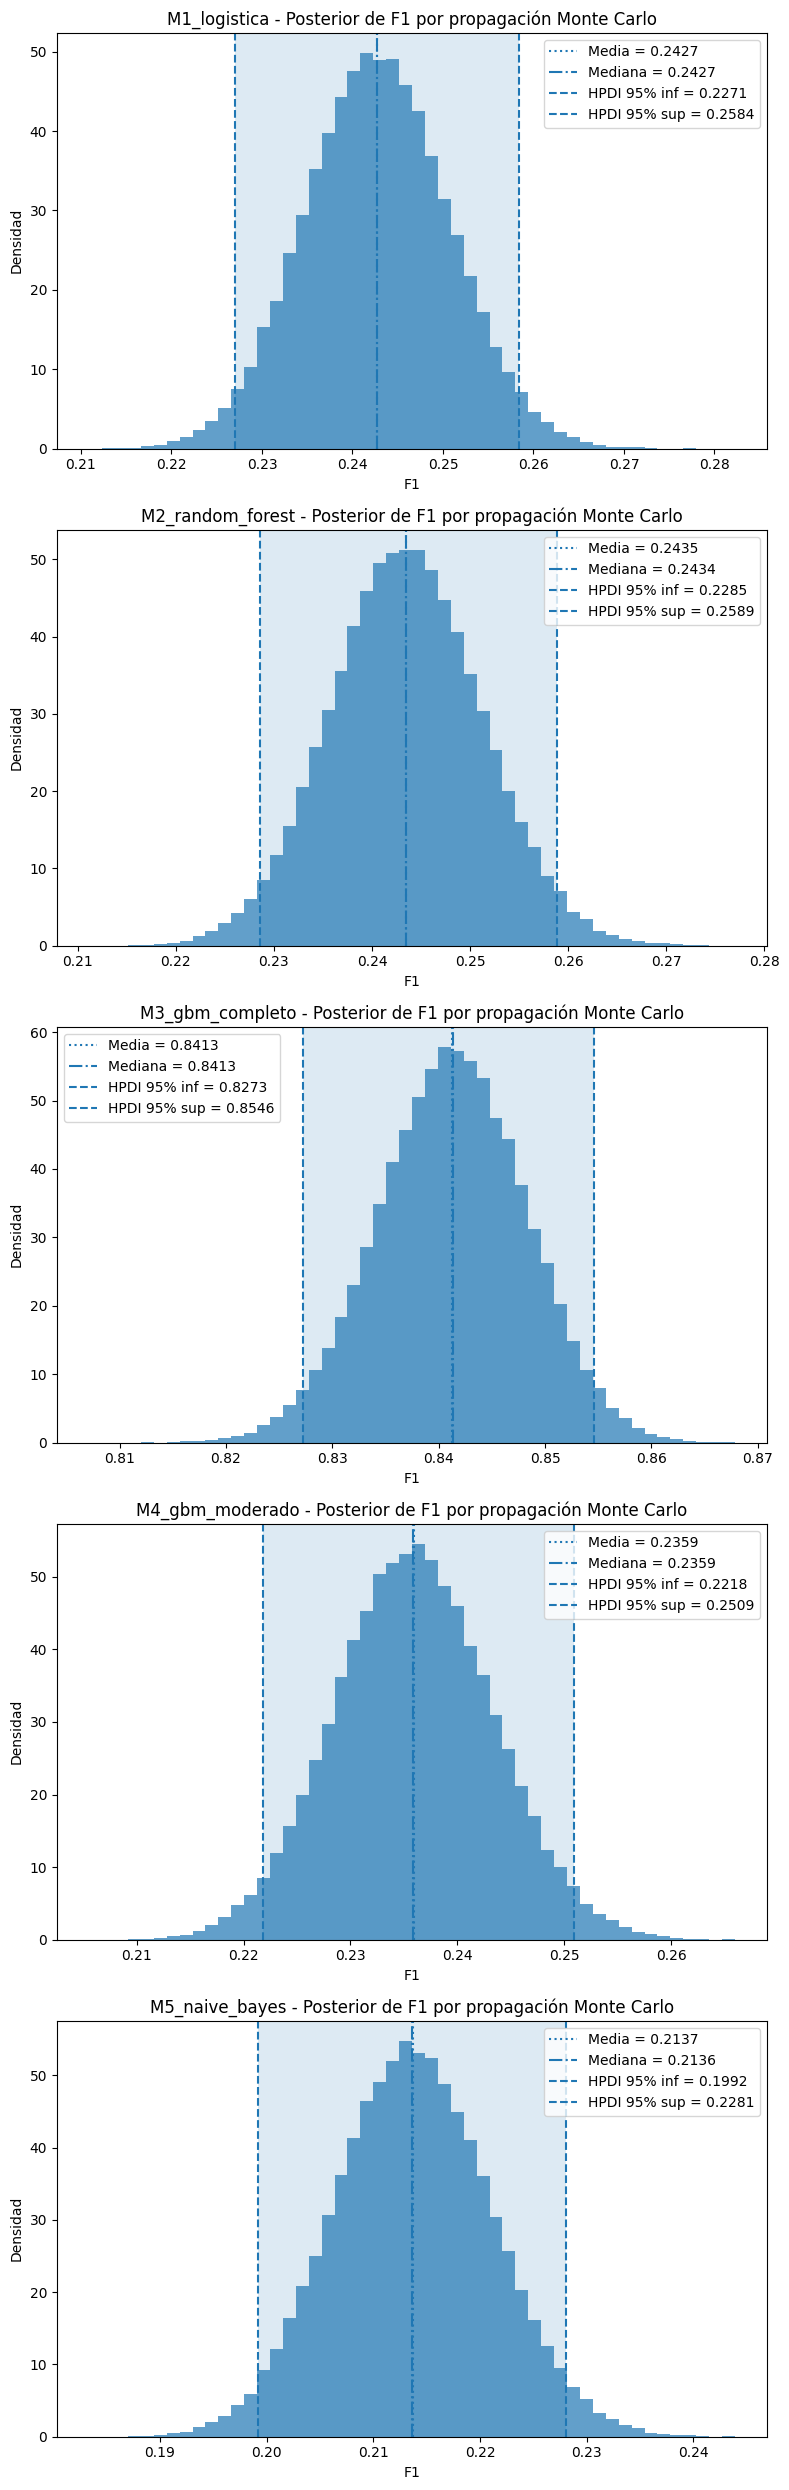

In [123]:
import numpy as np
import matplotlib.pyplot as plt

n_models = len(results)

fig, axes = plt.subplots(n_models, 1, figsize=(8, 5 * n_models))

# Si hay un solo modelo, axes no viene como lista
if n_models == 1:
    axes = [axes]

for ax, (model, res) in zip(axes, results.items()):
    
    f1_samples = res["f1_samples"]
    mean_f1 = res["mean_f1"]
    median_f1 = res["median_f1"]
    var_f1 = res["var_f1"]
    hpdi_f1 = res["hpdi_f1"]

    ax.hist(f1_samples, bins=50, density=True, alpha=0.7)

    ax.axvline(mean_f1, linestyle=":", label=f"Media = {mean_f1:.4f}")
    ax.axvline(median_f1, linestyle="-.", label=f"Mediana = {median_f1:.4f}")
    ax.axvline(hpdi_f1[0], linestyle="--", label=f"HPDI 95% inf = {hpdi_f1[0]:.4f}")
    ax.axvline(hpdi_f1[1], linestyle="--", label=f"HPDI 95% sup = {hpdi_f1[1]:.4f}")

    # Sombrear el HPDI
    ax.axvspan(hpdi_f1[0], hpdi_f1[1], alpha=0.15)

    # Texto dentro del gráfico

    

    ax.set_title(f"{model} - Posterior de F1 por propagación Monte Carlo")
    ax.set_xlabel("F1")
    ax.set_ylabel("Densidad")
    ax.legend()

plt.tight_layout()
plt.show()

### Paso 4. Replicar el procedimiento sobre los cinco modelos
Repetir los pasos 2 y 3 para M1, . . . , M5 sobre T0 entera. Producir una tabla con cinco filas (un
modelo por fila) y tres columnas: mediana F1, HPDI 95 % y conteos. Esa tabla es el primer panel
del análisis bayesiano y reconstruye, con incertidumbre cuantificada, la decisión que el banco
tomó en 2024 al elegir M3. Conviene comprobar que la mediana de M3 supera con holgura a las
de los otros cuatro: en T0 entera, M3 era efectivamente el modelo dominante.

### Tabla con 5 filas

In [124]:
# Producir una tabla con cinco filas (un
# modelo por fila) y tres columnas: mediana F1, HPDI 95 % y conteos.

Bayesian_table = pd.DataFrame({
    "Modelo": [],
    "Mediana F1": [],
    "HPDI 95%": [],
    "Conteos": []
})



for model, res in results.items():
    Bayesian_table = pd.concat([Bayesian_table, pd.DataFrame({
        "Modelo": [model],
        "Mediana F1": [f"{res['median_f1']:.4f}"],
        "HPDI 95%": [f"[{res['hpdi_f1'][0]:.4f}, {res['hpdi_f1'][1]:.4f}]"],
        "Conteos": [f"TP={res['TP']}, FP={res['FP']}, FN={res['FN']}"]
    })], ignore_index=True)


Bayesian_table




,Modelo,Mediana F1,HPDI 95%,Conteos
0,M1_logistica,0.2427,"[0.2271, 0.2584]","TP=347.0, FP=1065.0, FN=1101.0"
1,M2_random_forest,0.2434,"[0.2285, 0.2589]","TP=377.0, FP=1272.0, FN=1071.0"
2,M3_gbm_completo,0.8413,"[0.8273, 0.8546]","TP=1176.0, FP=170.0, FN=272.0"
3,M4_gbm_moderado,0.2359,"[0.2218, 0.2509]","TP=395.0, FP=1507.0, FN=1053.0"
4,M5_naive_bayes,0.2136,"[0.1992, 0.2281]","TP=330.0, FP=1312.0, FN=1118.0"


In [125]:
# Primer panel del análisis bayesiano y reconstruye, con incertidumbre cuantificada, la decisión que el banco tomó en 2024 al elegir M3.

# HPDI: Highest Posterior Density Interval. The 95% most probable values of a parameter. Mientras más estrecho menos incertidumbre del posible valor del parámetro.

# Mediana: ¿La masa de una distribución está centrada alrededor de un valor alto o bajo? Si es alto nos está diciendo que el modelo tiene un buen desempeño, si es bajo nos está diciendo que el modelo tiene un mal desempeño.





### Paso 5. Trayectoria mensual y trampa temporal
Repetir los pasos 2 a 4 mes por mes, sobre los meses 1 a 18 del archivo metricas_temporales.csv.
Para cada celda (modelo, mes) construir una posterior F1 por Monte Carlo y reportar mediana
con HPDI 95 %. Graficar la trayectoria temporal: cinco líneas (una por modelo) con sombras
HPDI, marcando con líneas verticales el mes 12 (fin de T0), el mes 13 (inicio del régimen alterado
por la campaña de phishing) y el mes 16 (estabilización del nuevo régimen).
Aquí aparece la trampa temporal del caso: si se promediara F1 sobre todo T1 (meses 13 a 18), el
promedio mezclaría la transición temprana con el régimen estabilizado, y no sería representativo
de ninguno de los dos. La trayectoria mensual lo expone visualmente: hay un cambio cualitativo
del orden de los modelos entre el régimen pre-cambio y el post-cambio. Reconocerlo y declararlo
es parte central del dictamen.

In [127]:
metricas_temporales = pd.read_csv("/Users/Usuario/Downloads/metricas_temporales.csv")

In [128]:
metricas_temporales

,modelo,mes,fase,n,n_fraude,f1,f1_med,f1_lo,f1_hi,precision,recall,auc_pr
0,M1_logistica,1,T0,51439,435,0.234848,0.231206,0.197288,0.272964,0.260504,0.213793,0.177202
1,M1_logistica,2,T0,48092,427,0.223881,0.223708,0.183145,0.259829,0.238727,0.210773,0.179768
2,M1_logistica,3,T0,50875,394,0.197889,0.198593,0.159882,0.237472,0.206044,0.190355,0.144582
3,M1_logistica,4,T0,51456,402,0.229219,0.226226,0.190837,0.269420,0.232143,0.226368,0.168400
4,M1_logistica,5,T0,52497,420,0.264741,0.265336,0.226278,0.307556,0.267640,0.261905,0.188016
...,...,...,...,...,...,...,...,...,...,...,...,...
115,M5_naive_bayes,20,T1,15664,186,0.189911,0.188412,0.130934,0.239562,0.211921,0.172043,0.144134
116,M5_naive_bayes,21,T1,14699,198,0.197605,0.194322,0.127255,0.265896,0.242647,0.166667,0.166070
117,M5_naive_bayes,22,T2,15330,233,0.076712,0.076713,0.041767,0.111829,0.106061,0.060086,0.065788
118,M5_naive_bayes,23,T2,15993,238,0.038781,0.035952,0.015101,0.059981,0.056911,0.029412,0.035908


In [ ]:
import numpy as np
from scipy.stats import beta

# Cantidad de simulaciones
S = 100_000

# Semilla reproducible
rng = np.random.default_rng(42)

for mes, modelo in metricas_temporales.groupby('modelo'):
    


    # Simular valores desde las posteriores
 

    # Propagación Monte Carlo a F1
    f1_samples = 2 * p_samples * r_samples / (p_samples + r_samples)

    # Guardar en results
    results[model]["p_samples"] = p_samples
    results[model]["r_samples"] = r_samples
    results[model]["f1_samples"] = f1_samples

### Paso 6. Posteriores y matriz de dominancia sobre la ventana operativa

Sobre la subventana operativa (meses 16 a 18), construir tres objetos:
1. Posteriores Beta-Binomial agregadas por modelo (TP, FP, FN sumados sobre los tres
meses). Reportar mediana y HPDI.
2. Densidades posteriores de F1 por modelo, graficadas en un mismo panel para ver el
solapamiento.
3. Matriz 5 × 5 de dominancia bayesiana P(F(i) 1 > F(j) 1) . Por cada par (i, j), calcular la
fracción de muestras conjuntas Monte Carlo en las que F(i) 1 > F(j) 1. La matriz reemplaza el
ranking por mediana con un objeto que cuantifica cuán probable es que un modelo supere
a otro, no sólo si su mediana es más alta.
Recordar que la matriz se construye sobre la ventana operativa, no sobre T0 ni sobre T1 entero.